# Data Preprocessing


This notebook covers the data pre-processing pipeline including dataset importing, data and image verification and analysis of demographic distributions.

In [1]:
# mount Googole Drive to gain access to the dataset stored in Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# unzip the file and import the dataset
import os

dataset = "/content/drive/MyDrive/IndividualProject/cxr"

if not os.path.exists(dataset):
    !unzip "/content/drive/MyDrive/IndividualProject/cxr.zip" -d "/content/drive/MyDrive/IndividualProject/"
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [3]:
# understand the contents in the dataset
!ls /content/drive/MyDrive/IndividualProject/cxr

annotations.csv		task_labels
effusion.csv		teaser.png
images			training_loss_atelectasis_20260227_190339.npy
images.hdf5		training_loss_atelectasis.npy
info.yaml		training_loss.npy
LICENSE			training_loss_v2.npy
original_splits		validation_auc_atelectasis_20260227_190339.npy
processed_data.csv	validation_auc_atelectasis.npy
processed_data_v3.csv	validation_auc.npy
splits			validation_auc_v2.npy
supplementary_material	validation_loss_atelectasis_20260227_190339.npy


# Dataset Exploration

Understand what is included in the cxr folder and the metadata included using annotations.csv and info.yaml file

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("/content/drive/MyDrive/IndividualProject/cxr/annotations.csv")
print(df.shape)
print(df.columns)
df.head()

(112120, 16)
Index(['filepath', 'split', 'tasks/disease labels', 'tasks/patient sex',
       'original_filepath', 'original_split', 'patient_id', 'bounding_box',
       'disease labels', 'finding_labels', 'follow-up_nb',
       'original_image_size', 'original_pixel_spacing', 'patient sex',
       'patient_age', 'view_position'],
      dtype='object')


,filepath,split,tasks/disease labels,tasks/patient sex,original_filepath,original_split,patient_id,bounding_box,disease labels,finding_labels,follow-up_nb,original_image_size,original_pixel_spacing,patient sex,patient_age,view_position
0,images/000000.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_000.png,train,1,NaN,Cardiomegaly,Cardiomegaly,0,"(2682,2749)","(0.143,0.143)",M,57,PA
1,images/000001.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]",1,images/00000001_001.png,train,1,NaN,Cardiomegaly|Emphysema,Cardiomegaly|Emphysema,1,"(2894,2729)","(0.143,0.143)",M,58,PA
2,images/000002.tiff,train,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_002.png,train,1,NaN,Cardiomegaly|Effusion,Cardiomegaly|Effusion,2,"(2500,2048)","(0.168,0.168)",M,58,PA
3,images/000003.tiff,train,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000002_000.png,train,2,NaN,NaN,No Finding,0,"(2500,2048)","(0.171,0.171)",M,80,PA
4,images/000004.tiff,test,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]",0,images/00000003_001.png,test,3,NaN,Hernia,Hernia,0,"(2500,2048)","(0.168,0.168)",F,74,PA


In [6]:
import yaml

with open("/content/drive/MyDrive/IndividualProject/cxr/info.yaml", "r") as f:
    info = yaml.safe_load(f)

info.keys()


dict_keys(['id', 'name', 'summary', 'domain', 'tasks', 'input_size', 'total_num_samples', 'splits_num_samples', 'original_splits_num_samples', 'domain_overlaps', 'subject_overlaps', 'license', 'project_website', 'download_url', 'DOI', 'original_data'])

In [7]:
info

{'id': 'cxr',
 'name': 'Chest X-ray Multi-disease',
 'summary': 'Chest X-ray dataset containing 112,120 frontal-view X-ray images with annotations for 14 common thorax diseases',
 'domain': 'Chest X-ray',
 'tasks': [{'task_name': 'disease labels',
   'task_target': 'MULTILABEL_CLASSIFICATION',
   'labels': {0: 'Atelectasis',
    1: 'Cardiomegaly',
    2: 'Effusion',
    3: 'Infiltration',
    4: 'Mass',
    5: 'Nodule',
    6: 'Pneumonia',
    7: 'Pneumothorax',
    8: 'Consolidation',
    9: 'Edema',
    10: 'Emphysema',
    11: 'Fibrosis',
    12: 'Pleural_Thickening',
    13: 'Hernia'}},
  {'task_name': 'patient sex',
   'task_target': 'BINARY_CLASSIFICATION',
   'labels': {0: 'F', 1: 'M'}}],
 'input_size': [1, 224, 224],
 'total_num_samples': 112120,
 'splits_num_samples': {'train': 73421, 'val': 13103, 'test': 25596},
 'original_splits_num_samples': {'train': 86524, 'val': 0, 'test': 25596},
 'domain_overlaps': ['pneumonia'],
 'subject_overlaps': [],
 'license': 'Creative Commons 

In [8]:
df.dtypes

,0
filepath,object
split,object
tasks/disease labels,object
tasks/patient sex,int64
original_filepath,object
original_split,object
patient_id,int64
bounding_box,object
disease labels,object
finding_labels,object


Find the number of postive cases for each disease labels. There is a total of 14 disease labels. If the list for the column "tasks/disease labels" is all 0, it indicates that the patient is healthy.

In [9]:
# map the index to each disease names
disease_names = info['tasks'][0]['labels']
print(disease_names)

{0: 'Atelectasis', 1: 'Cardiomegaly', 2: 'Effusion', 3: 'Infiltration', 4: 'Mass', 5: 'Nodule', 6: 'Pneumonia', 7: 'Pneumothorax', 8: 'Consolidation', 9: 'Edema', 10: 'Emphysema', 11: 'Fibrosis', 12: 'Pleural_Thickening', 13: 'Hernia'}


In [10]:
# create dictionary to store the disease counts for each label
import ast
disease_counts = {}

for row in df["tasks/disease labels"]:
  # convert the list from string to int type
  row = ast.literal_eval(row)

  for idx, value in enumerate(row):
    if value == 1:
      disease_name = disease_names[idx]

      if disease_name in disease_counts:
        disease_counts[disease_name] += 1
      else:
        disease_counts[disease_name] = 1

print(disease_counts)


{'Cardiomegaly': 2776, 'Emphysema': 2516, 'Effusion': 13317, 'Hernia': 227, 'Infiltration': 19894, 'Mass': 5782, 'Nodule': 6331, 'Atelectasis': 11559, 'Pneumothorax': 5302, 'Pleural_Thickening': 3385, 'Pneumonia': 1431, 'Fibrosis': 1686, 'Edema': 2303, 'Consolidation': 4667}


In [16]:
# print the dictionary in Series format, sorted in descending order based on the number of positive cases
series = pd.Series(disease_counts, name="Positive Cases")
series.sort_values(ascending=False)

,Positive Cases
Infiltration,19894
Effusion,13317
Atelectasis,11559
Nodule,6331
Mass,5782
Pneumothorax,5302
Consolidation,4667
Pleural_Thickening,3385
Cardiomegaly,2776
Emphysema,2516


In [17]:

# find the total number of patients with no finding
no_finding = (df['finding_labels'] == 'No Finding').sum()

print(no_finding)


60361


In [18]:
# create a new binary label column: 1 if Atelectasis is present, 0 if None
df["tasks/atelectasis_label"] = df["disease labels"].str.contains("Atelectasis", na=False).astype(int)

In [19]:
# check the number of postive cases in Atelectasis, verify it is 11559
df["tasks/atelectasis_label"].sum()

np.int64(11559)

In [20]:
# identify the proportion of positive atelectasis cases to negative cases
df["tasks/atelectasis_label"].value_counts(normalize=True)

,proportion
tasks/atelectasis_label,
0,0.896905
1,0.103095


# Verify Image

In [21]:
# try to load images and verify it is 224x224 pixels
import h5py
import random

with h5py.File("/content/drive/MyDrive/IndividualProject/cxr/images.hdf5", "r") as f:
  print("Keys in HDF5", list(f.keys()))

  images = f['images']
  random_index = random.randint(0, len(images) - 1)
  random_image = images[random_index]

  print("Random index:", random_index)
  print("Image shape:", random_image.shape)

Keys in HDF5 ['images']
Random index: 83916
Image shape: (224, 224)


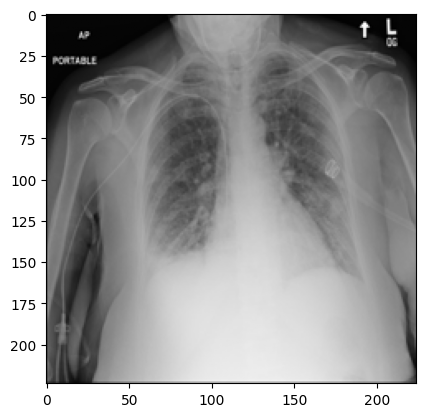

In [24]:
# visualise the image
import matplotlib.pyplot as plt

plt.imshow(random_image, cmap='gray')
plt.show()

Verify the dataset splits

In [25]:
!ls /content/drive/MyDrive/IndividualProject/cxr/splits

test.txt  train.txt  val.txt


In [26]:
# check what is include in each split
with open("/content/drive/MyDrive/IndividualProject/cxr/splits/train.txt") as f:
    for _ in range(5):
        print(f.readline().strip())

images/000000.tiff
images/000001.tiff
images/000002.tiff
images/000003.tiff
images/000012.tiff


In [27]:
# verify the size of each splits
def load_split(path):
    with open(path, "r") as f:
        return set(line.strip() for line in f)

split_dir = "/content/drive/MyDrive/IndividualProject/cxr/splits"

train_ids = load_split(f"{split_dir}/train.txt")
val_ids   = load_split(f"{split_dir}/val.txt")
test_ids  = load_split(f"{split_dir}/test.txt")

print("Train size:", len(train_ids))
print("Val size:", len(val_ids))
print("Test size:", len(test_ids))


Train size: 73421
Val size: 13103
Test size: 25596


In [28]:
# verify the total size is 112,120
total = len(train_ids) + len(val_ids) + len(test_ids)
print("Total cases:", total)

Total cases: 112120


In [ ]:
# verify the percentage of each split
df['split'].value_counts(normalize=True)

,proportion
split,
train,0.654843
test,0.228291
val,0.116866


Verify if there is any intersection of the patient's id across the splits to prevent data leakage.

In [31]:
print("Train ∩ Val:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Val ∩ Test:", len(val_ids & test_ids))


Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


# Atelectasis Distribution

In [32]:
# identify the distribution of positive atelectasis cases in each split
df.groupby('split')['tasks/atelectasis_label'].value_counts(normalize=True)

split  tasks/atelectasis_label
test   0                          0.871894
       1                          0.128106
train  0                          0.903543
       1                          0.096457
val    0                          0.908571
       1                          0.091429
Name: proportion, dtype: float64

# Sex Distribution

In [33]:
# identify the distribution of male and female in the overall dataset
df['patient sex'].value_counts(normalize=True)

,proportion
patient sex,
M,0.56493
F,0.43507


In [34]:
# identify the distribution of male and female in each splits
df.groupby('split')['patient sex'].value_counts(normalize=True)


split  patient sex
test   M              0.581419
       F              0.418581
train  M              0.557620
       F              0.442380
val    M              0.573685
       F              0.426315
Name: proportion, dtype: float64

# Age Distribution

In [35]:
df['age_split'] = df['patient_age'].apply(lambda x:'<50' if x < 50 else '>=50')
df['age_split'].value_counts(normalize=True)


,proportion
age_split,
<50,0.520344
>=50,0.479656


In [36]:
df.groupby('split')['age_split'].value_counts(normalize=True)

split  age_split
test   <50          0.514416
       >=50         0.485584
train  <50          0.526430
       >=50         0.473570
val    >=50         0.502175
       <50          0.497825
Name: proportion, dtype: float64

# Intersectional Group Distribution

In [37]:
df[['patient sex', 'age_split']].value_counts(normalize=True)

patient sex  age_split
M            <50          0.284998
             >=50         0.279932
F            <50          0.235346
             >=50         0.199724
Name: proportion, dtype: float64

In [38]:
df.groupby('split')[['patient sex', 'age_split']].value_counts(normalize=True)

split  patient sex  age_split
test   M            <50          0.298250
                    >=50         0.283169
       F            <50          0.216167
                    >=50         0.202414
train  M            <50          0.279470
                    >=50         0.278149
       F            <50          0.246959
                    >=50         0.195421
val    M            <50          0.290086
                    >=50         0.283599
       F            >=50         0.218576
                    <50          0.207739
Name: proportion, dtype: float64

In [40]:
# convert the modifed df to a new csv file which includes the binary atelectasis label column
new_csv_path = "/content/drive/MyDrive/IndividualProject/cxr/processed_data_v3.csv"

if os.path.exists(new_csv_path):
    print("The new csv file was created previously.")
else:
    df.to_csv(new_csv_path, index=False)

The new csv file was created previously.


In [41]:
# verify that it contains the atelectasis label column used for training
processed_data_v3 = pd.read_csv("/content/drive/MyDrive/IndividualProject/cxr/processed_data_v3.csv")
processed_data_v3.columns
processed_data_v3.head()

,filepath,split,tasks/disease labels,tasks/patient sex,original_filepath,original_split,patient_id,bounding_box,disease labels,finding_labels,follow-up_nb,original_image_size,original_pixel_spacing,patient sex,patient_age,view_position,tasks/atelectasis_label,tasks/pneumonia_label
0,images/000000.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_000.png,train,1,NaN,Cardiomegaly,Cardiomegaly,0,"(2682,2749)","(0.143,0.143)",M,57,PA,0,0
1,images/000001.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]",1,images/00000001_001.png,train,1,NaN,Cardiomegaly|Emphysema,Cardiomegaly|Emphysema,1,"(2894,2729)","(0.143,0.143)",M,58,PA,0,0
2,images/000002.tiff,train,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_002.png,train,1,NaN,Cardiomegaly|Effusion,Cardiomegaly|Effusion,2,"(2500,2048)","(0.168,0.168)",M,58,PA,0,0
3,images/000003.tiff,train,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000002_000.png,train,2,NaN,NaN,No Finding,0,"(2500,2048)","(0.171,0.171)",M,80,PA,0,0
4,images/000004.tiff,test,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]",0,images/00000003_001.png,test,3,NaN,Hernia,Hernia,0,"(2500,2048)","(0.168,0.168)",F,74,PA,0,0
